In [1]:
import pandas as pd 
import numpy as np

from sklearn.datasets import load_iris
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# import ensemble methods
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Import metrics for F1-score
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE

import warnings
warnings.filterwarnings("ignore") # to avoid warnings

In [2]:
df = pd.read_csv("conversion_data_train.csv")
df.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB


In [4]:
df.describe(include='all')

,country,age,new_user,source,total_pages_visited,converted
count,284580,284580.000000,284580.000000,284580,284580.000000,284580.000000
unique,4,NaN,NaN,3,NaN,NaN
top,US,NaN,NaN,Seo,NaN,NaN
freq,160124,NaN,NaN,139477,NaN,NaN
mean,NaN,30.564203,0.685452,NaN,4.873252,0.032258
std,NaN,8.266789,0.464336,NaN,3.341995,0.176685
min,NaN,17.000000,0.000000,NaN,1.000000,0.000000
25%,NaN,24.000000,0.000000,NaN,2.000000,0.000000
50%,NaN,30.000000,1.000000,NaN,4.000000,0.000000
75%,NaN,36.000000,1.000000,NaN,7.000000,0.000000


In [5]:
df.shape

(284580, 6)

In [6]:
convert = df.groupby("country")["converted"].agg(["count", "sum"])
convert = convert.rename(columns={"count": "total_users", "sum": "converted"})
convert

,total_users,converted
country,,
China,69122,89
Germany,11693,730
UK,43641,2291
US,160124,6070


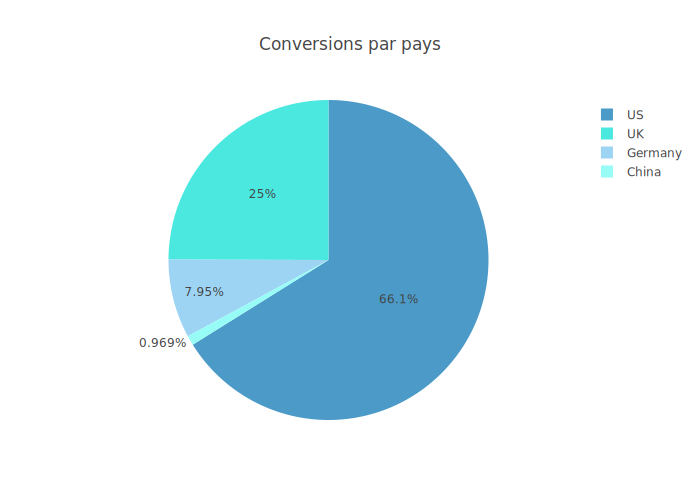

In [7]:
fig = px.pie(
    values=convert["converted"],
    names=convert.index,
    title="Conversions par pays"
)

fig.show()

In [8]:
convert_age = df.groupby("age")["converted"].agg(["count", "sum"])
convert_age.head()

,count,sum
age,,
17,6825,495
18,7662,492
19,8452,491
20,9131,525
21,9870,540


In [9]:
X = df.drop("converted", axis=1)
y = df["converted"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state = 0)

In [10]:
numeric_features = ["age", "total_pages_visited"]
categorical_features = ["country", "source", "new_user"]
"""
# Assurez-vous que X est votre DataFrame
for col_name in X.columns:
    dtype = X[col_name].dtype
    if dtype in ['int64', 'float64']:
        numeric_features.append(col_name)
    elif dtype == 'bool':
        numeric_features.append(col_name)  # Ou categorical_features.append(col_name) selon le traitement souhaité
    else:  # pour 'object' et d'autres types non numériques
        categorical_features.append(col_name)
"""

print('Found numeric features:', numeric_features)
print('Found categorical features:', categorical_features)

Found numeric features: ['age', 'total_pages_visited']
Found categorical features: ['country', 'source', 'new_user']


In [11]:
# Create pipeline for numeric features
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer()), 
    ('scaler', StandardScaler())
])

# Create pipeline for categorical features
categorical_transformer = Pipeline(
    steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # missing values will be replaced by most frequent value
    ('encoder', OneHotEncoder(drop='first')) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTransformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Preprocessings on train set
print("Performing preprocessings on train set...")
print(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print('...Done.')
print(X_train[0:5]) 
print()

# Preprocessings on test set
print("Performing preprocessings on test set...")
print(X_test.head()) 
X_test = preprocessor.transform(X_test) # Don't fit again !! 
print('...Done.')
print(X_test[0:5,:])

Performing preprocessings on train set...
       country  age  new_user  source  total_pages_visited
209053      US   28         1     Seo                    2
208135      US   18         1     Ads                   19
37779       US   28         0     Seo                    3
232576      US   33         1  Direct                    3
70804       US   26         1     Ads                    6
...Done.
[[-0.3116361  -0.86054723  0.          0.          1.          0.
   1.          1.        ]
 [-1.51987531  4.22680846  0.          0.          1.          0.
   0.          1.        ]
 [-0.3116361  -0.56129101  0.          0.          1.          0.
   1.          0.        ]
 [ 0.2924835  -0.56129101  0.          0.          1.          1.
   0.          1.        ]
 [-0.55328395  0.33647764  0.          0.          1.          0.
   0.          1.        ]]

Performing preprocessings on test set...
       country  age  new_user  source  total_pages_visited
163793      US   32         

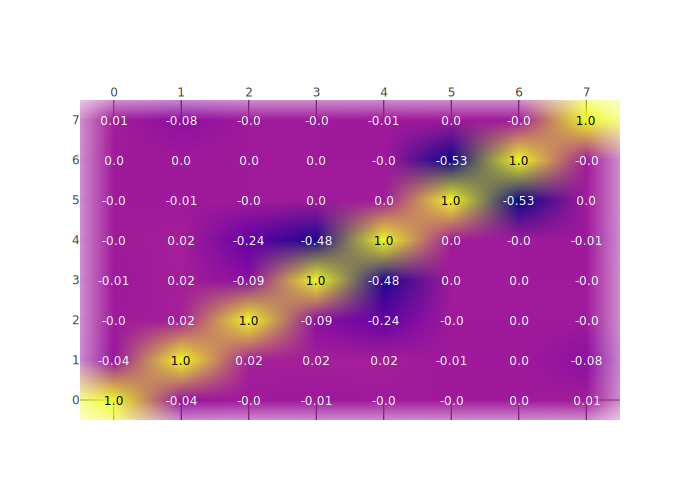

In [12]:
# Correlation matrix
corr_matrix = pd.DataFrame(X_train).corr().round(2)

import plotly.figure_factory as ff

fig = ff.create_annotated_heatmap(corr_matrix.values,
                                  x = corr_matrix.columns.tolist(),
                                  y = corr_matrix.index.tolist())


fig.show()

In [13]:
scores_df = pd.DataFrame(columns = ['model', 'f1_score', 'set'])

In [14]:
# Perform grid search
print("Grid search...")
random_forest = RandomForestClassifier(class_weight='balanced')  # Added class_weight for imbalanced data

# Grid of values to be tested
params = {
    'max_depth': [2, 4, 6, 8, 10],
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [2, 4, 8],
    'n_estimators': [10, 20, 40, 60, 80, 100]
}
print(params)
gridsearch = GridSearchCV(random_forest, param_grid = params, cv = 3, n_jobs=-1, verbose = 1, scoring='f1') # cv : the number of folds to be used for CV
gridsearch.fit(X_train, y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation F1-score : ", gridsearch.best_score_)
print()
# Calculate F1-score on train and test sets
y_train_pred = gridsearch.predict(X_train)
y_test_pred = gridsearch.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("F1-score on training set : ", train_f1)
print("F1-score on test set : ", test_f1)
print()
print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


# scores_df = scores_df.append({'model': 'random_forest', 'f1_score': train_f1, 'set': 'train'}, ignore_index = True)
# scores_df = scores_df.append({'model': 'random_forest', 'f1_score': test_f1, 'set': 'test'}, ignore_index = True)
# scores_df

new_rows = [
    {'model': 'random_forest', 'f1_score': train_f1, 'set': 'train'},
    {'model': 'random_forest', 'f1_score': test_f1, 'set': 'test'}
]

scores_df = pd.concat([scores_df, pd.DataFrame(new_rows)], ignore_index=True)
scores_df

Grid search...
{'max_depth': [2, 4, 6, 8, 10], 'min_samples_leaf': [1, 2, 5], 'min_samples_split': [2, 4, 8], 'n_estimators': [10, 20, 40, 60, 80, 100]}
Fitting 3 folds for each of 270 candidates, totalling 810 fits
...Done.
Best hyperparameters :  {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 40}
Best validation F1-score :  0.5763200115285502

F1-score on training set :  0.5784475455883009
F1-score on test set :  0.5564753004005341

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     68850
           1       0.40      0.91      0.56      2295

    accuracy                           0.95     71145
   macro avg       0.70      0.93      0.77     71145
weighted avg       0.98      0.95      0.96     71145



,model,f1_score,set
0,random_forest,0.578448,train
1,random_forest,0.556475,test


In [15]:
print('Training Bagging of decision tree...')
decision_tree = DecisionTreeClassifier(max_depth = 8, min_samples_leaf = 1, min_samples_split = 4, class_weight='balanced')
bagging = BaggingClassifier(estimator=decision_tree, n_estimators = 20)
bagging.fit(X_train, y_train)
print("...Done.")

# Calculate F1-score
y_train_pred = bagging.predict(X_train)
y_test_pred = bagging.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("F1-score on training set : ", train_f1)
print("F1-score on test set : ", test_f1)

new_rows = [
    {'model': 'bagging_dt', 'f1_score': train_f1, 'set': 'train'},
    {'model': 'bagging_dt', 'f1_score': test_f1, 'set': 'test'}
]

scores_df = pd.concat([scores_df, pd.DataFrame(new_rows)], ignore_index=True)
scores_df

Training Bagging of decision tree...
...Done.
F1-score on training set :  0.5360935944241619
F1-score on test set :  0.5290098148838365


,model,f1_score,set
0,random_forest,0.578448,train
1,random_forest,0.556475,test
2,bagging_dt,0.536094,train
3,bagging_dt,0.529010,test


In [16]:
# Perform grid search
print("Grid search...")
logistic_regression = LogisticRegression(max_iter = 1000, class_weight='balanced')
adaboost_logreg = AdaBoostClassifier(logistic_regression)

# Grid of values to be tested
params = {
    'estimator__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
    'n_estimators': [5, 10, 20, 40, 60, 80, 100]
}
print(params)
gridsearch = GridSearchCV(adaboost_logreg, param_grid = params, cv = 3, n_jobs=-1, verbose = 1, scoring='f1')
gridsearch.fit(X_train, y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation F1-score : ", gridsearch.best_score_)
print()

# Calculate F1-score
y_train_pred = gridsearch.predict(X_train)
y_test_pred = gridsearch.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("F1-score on training set : ", train_f1)
print("F1-score on test set : ", test_f1)

new_rows = [
    {'model': 'adaboost_logreg', 'f1_score': train_f1, 'set': 'train'},
    {'model': 'adaboost_logreg', 'f1_score': test_f1, 'set': 'test'}
]

scores_df = pd.concat([scores_df, pd.DataFrame(new_rows)], ignore_index=True)
scores_df

Grid search...
{'estimator__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0], 'n_estimators': [5, 10, 20, 40, 60, 80, 100]}
Fitting 3 folds for each of 56 candidates, totalling 168 fits
...Done.
Best hyperparameters :  {'estimator__C': 0.1, 'n_estimators': 5}
Best validation F1-score :  0.525231626295123

F1-score on training set :  0.5246398786959818
F1-score on test set :  0.521105527638191


,model,f1_score,set
0,random_forest,0.578448,train
1,random_forest,0.556475,test
2,bagging_dt,0.536094,train
3,bagging_dt,0.529010,test
4,adaboost_logreg,0.524640,train
5,adaboost_logreg,0.521106,test


In [ ]:
# Perform grid search
print("Grid search...")
gradientboost = GradientBoostingClassifier()

# Grid of values to be tested
params = {
    'max_depth': [8],
    'min_samples_leaf': [3],
    'min_samples_split': [6, 8, 10],
    'n_estimators': [50, 100, 200]
}
print(params)
gridsearch = GridSearchCV(gradientboost, param_grid = params, cv = 3, n_jobs=-1, verbose = 1, scoring='f1')
gridsearch.fit(X_train, y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation F1-score : ", gridsearch.best_score_)
print()

# Calculate F1-score
y_train_pred = gridsearch.predict(X_train)
y_test_pred = gridsearch.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("F1-score on training set : ", train_f1)
print("F1-score on test set : ", test_f1)

new_rows = [
    {'model': 'gradient_boost', 'f1_score': train_f1, 'set': 'train'},
    {'model': 'gradient_boost', 'f1_score': test_f1, 'set': 'test'}
]

scores_df = pd.concat([scores_df, pd.DataFrame(new_rows)], ignore_index=True)
scores_df

Grid search...
{'max_depth': [8], 'min_samples_leaf': [3], 'min_samples_split': [6, 8, 10], 'n_estimators': [50, 100, 200]}
Fitting 3 folds for each of 9 candidates, totalling 27 fits


In [ ]:
# Perform grid search
print("Grid search...")
xgboost = XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]))  # Handle imbalanced data

# Grid of values to be tested
params = {
    'max_depth': [6, 8, 10],                    
    'min_child_weight': [2, 5],                 
    'n_estimators': [100, 200],                 
    'learning_rate': [0.01, 0.1],              
    'subsample': [0.8],                         
    'colsample_bytree': [0.8]                   
}
print(params)
gridsearch = GridSearchCV(xgboost, param_grid = params, cv = 3, n_jobs=-1, verbose = 1, scoring='f1')
gridsearch.fit(X_train, y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation F1-score : ", gridsearch.best_score_)
print()

# Calculate F1-score
y_train_pred = gridsearch.predict(X_train)
y_test_pred = gridsearch.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("F1-score on training set : ", train_f1)
print("F1-score on test set : ", test_f1)

new_rows = [
    {'model': 'xgboost', 'f1_score': train_f1, 'set': 'train'},
    {'model': 'xgboost', 'f1_score': test_f1, 'set': 'test'}
]

scores_df = pd.concat([scores_df, pd.DataFrame(new_rows)], ignore_index=True)
scores_df

Grid search...
{'max_depth': [4, 6, 8, 10], 'min_child_weight': [1, 2, 4, 6, 8], 'n_estimators': [2, 4, 6, 8, 10, 12]}
Fitting 3 folds for each of 120 candidates, totalling 360 fits
...Done.
Best hyperparameters :  {'max_depth': 10, 'min_child_weight': 2, 'n_estimators': 8}
Best validation F1-score :  0.5261213126901232

F1-score on training set :  0.5461847389558233
F1-score on test set :  0.5217283644917667


,model,f1_score,set
0,random_forest,0.578448,train
1,random_forest,0.556475,test
2,bagging_dt,0.536094,train
3,bagging_dt,0.529010,test
4,adaboost_logreg,0.524640,train
5,adaboost_logreg,0.521106,test
6,gradient_boost,0.755159,train
7,gradient_boost,0.726721,test
8,xgboost,0.546185,train
9,xgboost,0.521728,test


In [19]:
scores_df = scores_df.sort_values(by = ['set', 'f1_score'], ascending = False)
scores_df

,model,f1_score,set
6,gradient_boost,0.755159,train
0,random_forest,0.578448,train
8,xgboost,0.546185,train
2,bagging_dt,0.536094,train
4,adaboost_logreg,0.524640,train
7,gradient_boost,0.726721,test
1,random_forest,0.556475,test
3,bagging_dt,0.529010,test
9,xgboost,0.521728,test
5,adaboost_logreg,0.521106,test


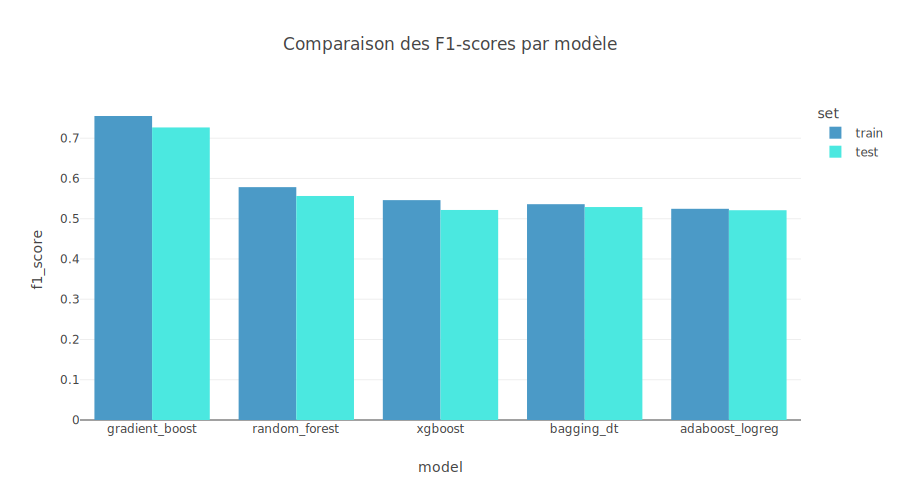

In [20]:
px.bar(scores_df, x = "model", y = 'f1_score', color = 'set', barmode = 'group', width = 900, title='Comparaison des F1-scores par modèle')